Loading Data (MNIST 0 and 1)...

Experiment 1: Sigmoid (Vanishing Gradient Test)
Experiment 2: ReLU (Stable Learning)


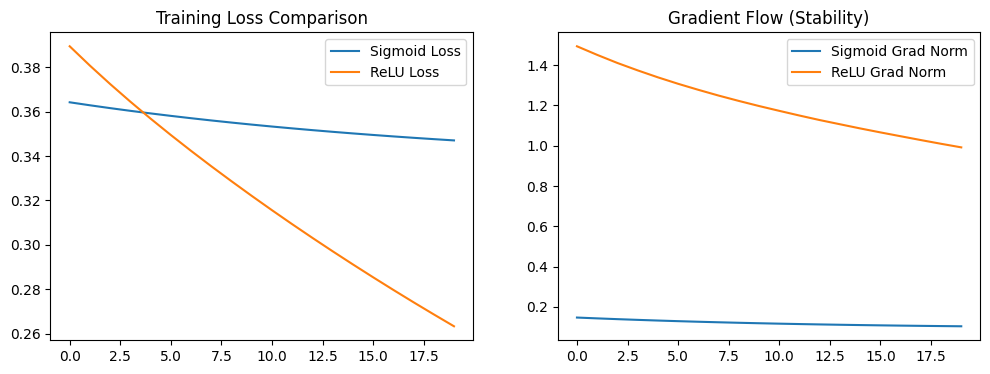

Final Val Accuracy (ReLU): 97.65%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 1: Data Preparation (MNIST subset for binary classification) ---
# Hum 0 aur 1 digits ko classify karenge taaki task binary rahe
from sklearn.datasets import fetch_openml
print("Loading Data (MNIST 0 and 1)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_all, y_all = mnist.data, mnist.target.astype(int)

# Filter only 0s and 1s
mask = (y_all == 0) | (y_all == 1)
X, y = X_all[mask] / 255.0, y_all[mask].reshape(-1, 1)

# Split: 70% Train, 15% Val, 15% Test (Mandatory)
n = len(X)
indices = np.random.permutation(n)
train_idx, val_idx = int(0.7*n), int(0.85*n)

X_train, y_train = X[indices[:train_idx]], y[indices[:train_idx]]
X_val, y_val = X[indices[train_idx:val_idx]], y[indices[train_idx:val_idx]]
X_test, y_test = X[indices[val_idx:]], y[indices[val_idx:]]

# --- STEP 2: Activation Functions & Gradients ---
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_der(a):
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def relu_der(z):
    return (z > 0).astype(float)

# --- STEP 3: The Model Class (Fully Connected / Dense) ---
class DenseNetwork:
    def __init__(self, layers, activation='relu'):
        self.params = {}
        self.activation = activation
        for i in range(1, len(layers)):
            # He Initialization for ReLU, Xavier for Sigmoid
            scale = np.sqrt(2./layers[i-1]) if activation == 'relu' else np.sqrt(1./layers[i-1])
            self.params[f'W{i}'] = np.random.randn(layers[i-1], layers[i]) * scale
            self.params[f'b{i}'] = np.zeros((1, layers[i]))

    def forward(self, X):
        cache = {'A0': X}
        for i in range(1, len(self.params)//2 + 1):
            z = cache[f'A{i-1}'] @ self.params[f'W{i}'] + self.params[f'b{i}']
            a = relu(z) if (self.activation == 'relu' and i < len(self.params)//2) else sigmoid(z)
            cache[f'Z{i}'] = z
            cache[f'A{i}'] = a
        return cache

    def backward(self, cache, y):
        grads = {}
        L = len(self.params)//2
        N = y.shape[0]

        # Output layer error
        dA = cache[f'A{L}'] - y

        for i in range(L, 0, -1):
            grads[f'dW{i}'] = (cache[f'A{i-1}'].T @ dA) / N
            grads[f'db{i}'] = np.sum(dA, axis=0, keepdims=True) / N

            if i > 1:
                # Backprop to hidden layer
                dA = (dA @ self.params[f'W{i}'].T) * (relu_der(cache[f'Z{i-1}']) if self.activation == 'relu' else sigmoid_der(cache[f'A{i-1}']))

        # Calculate Gradient Norm (Frobenius Norm) for analysis
        grad_norm = np.sqrt(np.sum([np.sum(g**2) for g in grads.values()]))
        return grads, grad_norm

# --- STEP 4: Training Loop with Comparisons ---
def train_model(config, epochs=20, lr=0.01):
    model = DenseNetwork(config['layers'], activation=config['activation'])
    history = {'train_loss': [], 'val_acc': [], 'grad_norms': []}

    for epoch in range(epochs):
        # Forward & Backward
        cache = model.forward(X_train)
        loss = -np.mean(y_train * np.log(cache[f'A{len(config["layers"])-1}'] + 1e-10))
        grads, g_norm = model.backward(cache, y_train)

        # Update (SGD)
        for i in range(1, len(config['layers'])):
            model.params[f'W{i}'] -= lr * grads[f'dW{i}']
            model.params[f'b{i}'] -= lr * grads[f'db{i}']

        # Validation
        val_cache = model.forward(X_val)
        val_preds = (val_cache[f'A{len(config["layers"])-1}'] > 0.5).astype(int)
        val_acc = np.mean(val_preds == y_val)

        history['train_loss'].append(loss)
        history['val_acc'].append(val_acc)
        history['grad_norms'].append(g_norm)

    return history

# --- STEP 5: Run Experiments (Sigmoid vs ReLU) ---
print("\nExperiment 1: Sigmoid (Vanishing Gradient Test)")
hist_sig = train_model({'layers': [784, 128, 64, 1], 'activation': 'sigmoid'})

print("Experiment 2: ReLU (Stable Learning)")
hist_relu = train_model({'layers': [784, 128, 64, 1], 'activation': 'relu'})

# --- STEP 6: Plotting Results ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_sig['train_loss'], label='Sigmoid Loss')
plt.plot(hist_relu['train_loss'], label='ReLU Loss')
plt.title("Training Loss Comparison")
plt.legend()



plt.subplot(1, 2, 2)
plt.plot(hist_sig['grad_norms'], label='Sigmoid Grad Norm')
plt.plot(hist_relu['grad_norms'], label='ReLU Grad Norm')
plt.title("Gradient Flow (Stability)")
plt.legend()
plt.show()



print(f"Final Val Accuracy (ReLU): {hist_relu['val_acc'][-1]*100:.2f}%")